In [71]:
import random
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display 


from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile 
from qiskit_aer import Aer
from qiskit_aer import AerSimulator


from qiskit.quantum_info import Statevector, partial_trace, state_fidelity

from qiskit_aer.noise import NoiseModel, depolarizing_error

# 1. Quantum teleportation

Quantum teleportation transfers an unknown quantum state from Alice’s qubit to Bob’s qubit using a shared entangled Bell pair. Alice measures her qubits and sends two classical bits to Bob. Bob uses these bits to apply the correct operations and recover the original quantum state.

We are going to use Qiskit to implement the quantum teleportation protocol.





**Step 1: Prepare Alice's Random Quantum State**

Alice's qubit: ((-0.22177448675241734-0.36950313967167453j))|0> + ((-0.9012679379028653+0.04471700914410482j))|1>


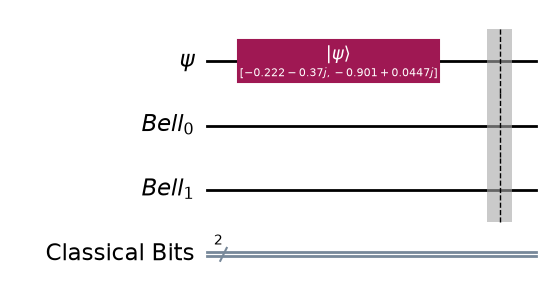

In [72]:

a1 = random.random()*2 -1 
a2 = random.random()*2 -1
b1 = random.random()*2 -1
b2 = random.random()*2 -1

# Normalize the amplitudes:
norm = (a1**2 + a2**2 + b1**2 + b2**2)**0.5

# The amplitudes are:
alpha = complex(a1/norm,a2/norm)                                #Amplitude for |0> 
beta = complex(b1/norm,b2/norm)                                 #Amplitude for |1>

# Create the quantum and classical registers:
psi = QuantumRegister(1, name  = 'ψ')                         # |0>
bell = QuantumRegister(2, name = 'Bell')                   # |00>
c = ClassicalRegister(2, name  = 'Classical Bits')              # 0 , 0 


# Create the teleportation circuit:
teleport_qc = QuantumCircuit(psi, bell, c)



# Initialize Alice's qubit:
teleport_qc.initialize([alpha,beta], psi)                        # |psi>=\alpha|0> + \beta|1>

teleport_qc.barrier()

initial_qc = teleport_qc.copy()


print(f"Alice's qubit: ({alpha})|0> + ({beta})|1>")         
display(teleport_qc.draw('mpl'))




**Step 2: Build the Quantum Teleportation Circuit**

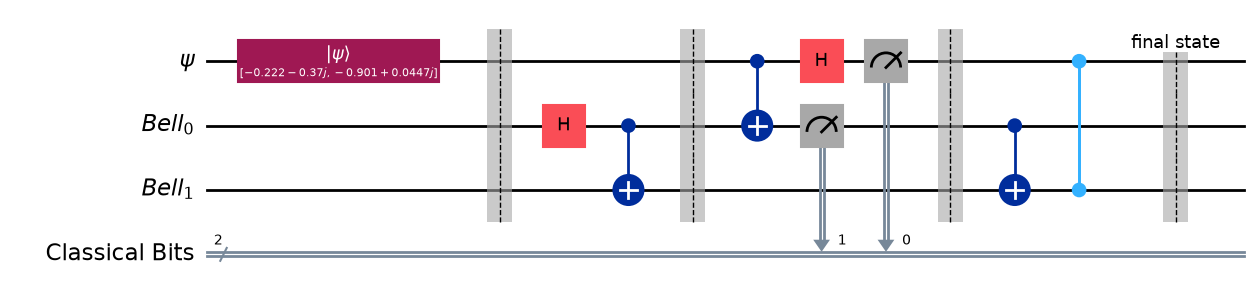

In [73]:
# Now we need to create the entanglement state (Bell pair: (|00>+|11>)/sqrt(2)):
def create_bell_pair(qc, bell):
    qc.h(bell[0])
    qc.cx(bell[0], bell[1])


# Alice applies gates and then measures her original qubit(psi) and her shared of the Bell state and stores them in classical bits to send them to Bob:
def alice_operations(qc, psi, bell, c):
    qc.cx(psi[0], bell[0])
    qc.h(psi[0])
    qc.measure([psi[0],bell[0]], c)


# Now that Bob receives the classical information, he applies his gates depending on that information received from Alice:
# (these two lines are implementing the same conditional corrections of the theory coherently, using the measured Alice qubits as controls.)
def bob_corrections(qc, psi, bell):
    qc.cx(bell[0], bell[1])
    qc.cz(psi[0], bell[1])

teleport_qc = initial_qc.copy()


create_bell_pair(teleport_qc, bell)
teleport_qc.barrier()            

alice_operations(teleport_qc, psi, bell, c)
teleport_qc.barrier()

bob_corrections(teleport_qc, psi, bell)                 



teleport_qc.save_statevector(label="final state")
teleport_qc.draw(output='mpl')


**Step 3: Simulate the Teleportation Circuit**

In [74]:
backend = Aer.get_backend("aer_simulator")

transpiled_teleport_qc = transpile(teleport_qc, backend)

job = backend.run(transpiled_teleport_qc)
result = job.result()

statevector = result.data(transpiled_teleport_qc)["final state"]    

# The statevector represents the entire final 3-qubit system, where bell[1] is Bob's qubit containing the teleported state.
print(statevector)

Statevector([-0.22177449-0.36950314j,  0.        +0.j        ,
              0.        -0.j        ,  0.        +0.j        ,
             -0.90126794+0.04471701j, -0.        +0.j        ,
             -0.        +0.j        , -0.        +0.j        ],
            dims=(2, 2, 2))


**Step 4: Fidelity verification**

In [75]:
# Reconstruct Alice's original state:
original_state = Statevector([alpha, beta])


# Extract Bob's qubit from the final 3-qubit state:
final_state = Statevector(statevector)


# Trace out Alice's two qubits to have Bob's state:
bob_state = partial_trace(final_state, [0, 1])


# Calculate the fidelity between Alice's original state and Bob's final state:
fidelity = state_fidelity(original_state, bob_state)



print(f"Teleportation fidelity: {fidelity:.6f}")                 # For an ideal simulation we get 1.0.

Teleportation fidelity: 1.000000


**Step 5: Simulate Teleportation with Quantum Noise**

In [ ]:
# Define error probabilities:
error_1q = 0.01   # 1% error probability for single-qubit gates
error_2q = 0.02   # 2% error probability for two-qubit gates


# Create depolarizing errors
single_qubit_error = depolarizing_error(error_1q, 1)
two_qubit_error = depolarizing_error(error_2q, 2)


# Create the noise model
noise_model = NoiseModel()

#For 1-qubit gte:
noise_model.add_all_qubit_quantum_error(
    single_qubit_error,
    ["h"]
)
#For 2-qubits gate:
noise_model.add_all_qubit_quantum_error(
    two_qubit_error,
    ["cx", "cz"]
)



# Build a new teleportation circuit for the noisy simulation considering density matrix:
noisy_qc = initial_qc.copy()

create_bell_pair(noisy_qc, bell)
noisy_qc.barrier()

alice_operations(noisy_qc, psi, bell, c)
noisy_qc.barrier()

bob_corrections(noisy_qc, psi, bell)


# Save the final state as a density matrix:
noisy_qc.save_density_matrix(label="noisy_final_state")


# Create a density-matrix simulator with the noise model:
noisy_backend = AerSimulator(
    method="density_matrix",
    noise_model=noise_model
)


# Transpile and run:
transpiled_noisy_qc = transpile(noisy_qc, noisy_backend)

job = noisy_backend.run(transpiled_noisy_qc)
result = job.result()


# Get the final noisy density matrix:
noisy_final_state = result.data(
    transpiled_noisy_qc
)["noisy_final_state"]


# Extract Bob's qubit:
bob_noisy_state = partial_trace(
    noisy_final_state,
    [0, 1]
)


# Compare Bob's noisy state with Alice's original state:
noisy_fidelity = state_fidelity(
    original_state,
    bob_noisy_state
)


print(f"Ideal teleportation fidelity: {fidelity:.6f}")
print(f"Noisy teleportation fidelity: {noisy_fidelity:.6f}")


Ideal teleportation fidelity: 1.000000
Noisy teleportation fidelity: 0.955633
